<a href="https://colab.research.google.com/github/ADlio1408/Meme-Virality/blob/main/SocSync.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install opencv-python-headless joblib gradio matplotlib seaborn scikit-learn

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving socialsync.csv to socialsync.csv


In [ ]:
import pandas as pd

df = pd.read_csv(list(uploaded.keys())[0])
df.head()

,subreddit,title,url,upvotes,comments,author,created_utc,engagement,label,image_path,brightness,contrast,edge_density,face_count,feature_label
0,memes,what a simple design,https://i.redd.it/y6wed616wytf1.jpeg,5744,72,TheFallenSpartan01,1759963867,5816,1,preprocessed_images\meme_1.jpg,112.812195,78.615239,0.024159,6.0,average
1,memes,multibillion dollar company btw,https://i.redd.it/fmox6f4r3xtf1.jpeg,21338,153,StopShoutingCrofty,1759942285,21491,1,preprocessed_images\meme_2.jpg,217.352837,82.779026,0.049871,0.0,viral
2,memes,when do we get cyberpsychosis,https://i.redd.it/pyyrjx84ywtf1.jpeg,6492,133,Moth_LovesLamp,1759940349,6625,1,preprocessed_images\meme_5.jpg,191.978016,88.879322,0.045357,2.0,average
3,memes,oh look its bill burr,https://i.redd.it/5kzlfz8w9wtf1.jpeg,8150,283,Klausensen,1759932163,8433,1,preprocessed_images\meme_7.jpg,155.061705,93.532061,0.070769,1.0,average
4,memes,priorities,https://i.redd.it/kwjh62um8wtf1.png,7505,246,FirefighterLevel8450,1759931745,7751,1,preprocessed_images\meme_8.jpg,64.949616,79.732204,0.068352,1.0,average


In [ ]:
X = df[['brightness', 'contrast', 'edge_density', 'face_count']]
y = df['label']
print("Features:", X.shape, "Target:", y.shape)

Features: (646, 4) Target: (646,)


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train_scaled, y_train)

y_pred = rf.predict(X_test_scaled)

Accuracy: 0.5769230769230769
              precision    recall  f1-score   support

           0       0.57      0.51      0.54        63
           1       0.58      0.64      0.61        67

    accuracy                           0.58       130
   macro avg       0.58      0.57      0.57       130
weighted avg       0.58      0.58      0.57       130



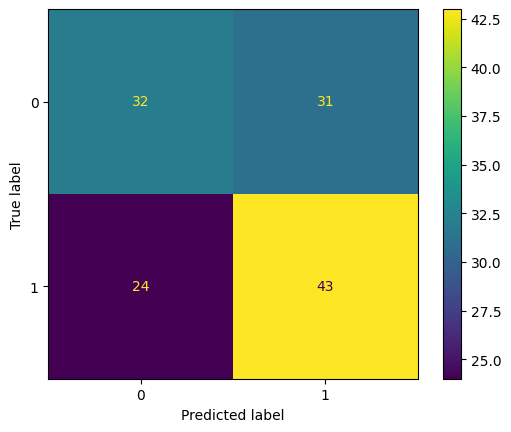

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

ConfusionMatrixDisplay.from_estimator(rf, X_test_scaled, y_test)
plt.show()

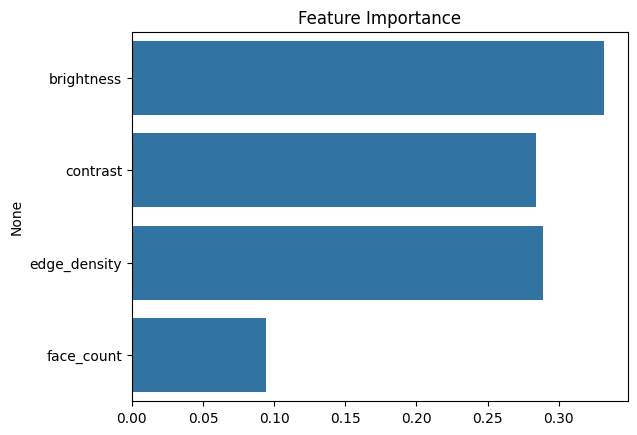

In [ ]:
import seaborn as sns

importances = pd.Series(rf.feature_importances_, index=X.columns)

sns.barplot(x=importances.values, y=importances.index)
plt.title("Feature Importance")
plt.show()

In [ ]:
import joblib

joblib.dump(rf, "rfmemeimage_model.pkl")
joblib.dump(scaler, "imagesscaler.pkl")

print("Model and scaler saved!")

Model and scaler saved!


In [ ]:
files.download("rfmemeimage_model.pkl")
files.download("imagesscaler.pkl")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
uploaded_img = files.upload()
img_path = list(uploaded_img.keys())[0]

Saving mwtyfbjarytf1.png to mwtyfbjarytf1.png


In [ ]:
import cv2
import numpy as np

img = cv2.imread(img_path)
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

brightness = np.mean(gray)
contrast = np.std(gray)

edges = cv2.Canny(gray, 100, 200)
edge_density = np.sum(edges > 0) / edges.size

face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + "haarcascade_frontalface_default.xml")
faces = face_cascade.detectMultiScale(gray, 1.3, 5)
face_count = len(faces)

print(brightness, contrast, edge_density, face_count)

61.27965910204082 74.5247676157021 0.028055510204081632 0


In [ ]:
import numpy as np
import pandas as pd

rf_loaded = joblib.load("rfmemeimage_model.pkl")
scaler_loaded = joblib.load("imagesscaler.pkl")

X_new = pd.DataFrame([{
    "brightness": brightness,
    "contrast": contrast,
    "edge_density": edge_density,
    "face_count": face_count
}])

X_new_scaled = scaler_loaded.transform(X_new)
prediction = rf_loaded.predict(X_new_scaled)[0]
proba = rf_loaded.predict_proba(X_new_scaled)[0][1]

print("🔥 VIRAL" if prediction == 1 else "😐 NOT VIRAL")
print(f"Confidence: {proba*100:.2f}%")

😐 NOT VIRAL
Confidence: 13.50%


In [ ]:
import imageio
import base64
from IPython.display import HTML, display
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# -----------------------------------------------------------
# 1. BUILD SPARSE GRAPH (much fewer edges)
# -----------------------------------------------------------
import networkx as nx
from sklearn.metrics.pairwise import cosine_similarity

df_small = df.sample(25, random_state=42).reset_index(drop=True)

graph_features = df_small[['brightness', 'contrast', 'edge_density', 'face_count']].values
sim = cosine_similarity(graph_features)

G = nx.Graph()

for i in range(len(df_small)):
    G.add_node(i, viral=int(df_small['label'][i]))

# HIGH threshold = sparse graph
threshold = 0.94
for i in range(len(df_small)):
    for j in range(i+1, len(df_small)):
        if sim[i][j] > threshold:
            G.add_edge(i, j, weight=float(sim[i][j]))

print("Nodes:", len(G.nodes), "Edges:", len(G.edges))

Nodes: 25 Edges: 233


In [ ]:
import numpy as np
import math

def node_color(strength):
    # strength: 0 → 1
    # smooth gradient
    r = min(255, int(255 * strength))
    g = int(200 * (1-strength))
    b = 50
    return f"#{r:02x}{g:02x}{b:02x}"

def node_size_base(strength):
    return 300 + int(300 * strength)

def node_glow(strength):
    # slight bright halo effect
    return min(1.0, strength + 0.3)

In [ ]:
def simulate_diffusion(G, viral, start_node=0):
    steps = 18 if viral == 1 else 6
    base_prob = 0.28 if viral == 1 else 0.03

    states = {n: 0 for n in G.nodes}
    strength = {n: 0.0 for n in G.nodes}

    states[start_node] = 1
    strength[start_node] = 1.0

    history = []

    for step in range(steps):
        new_states = states.copy()
        new_strength = strength.copy()

        for node in G.nodes:
            if states[node] == 1:
                for nbr in G[node]:
                    prob = base_prob * G[node][nbr]['weight']
                    if states[nbr] == 0 and np.random.rand() < prob:
                        new_states[nbr] = 1
                        new_strength[nbr] = min(1.0, new_strength[node]*0.8)

        # smooth fade for active nodes
        for n in new_strength:
            if new_states[n] == 1:
                new_strength[n] = min(1.0, new_strength[n] + 0.15)

        states = new_states
        strength = new_strength

        history.append((states.copy(), strength.copy()))

    return history

In [ ]:
def plot_step(G, step, frame_num):
    states, strength = step

    # rotating dynamic layout per frame
    angle = frame_num * 0.15
    pos = nx.spring_layout(G, k=0.6, iterations=20, seed=10)
    pos = {n: (math.cos(angle)*x - math.sin(angle)*y,
               math.sin(angle)*x + math.cos(angle)*y)
           for n,(x,y) in pos.items()}

    node_colors = [node_color(strength[n]) for n in G.nodes]
    node_sizes = [node_size_base(strength[n]) for n in G.nodes]

    fig, ax = plt.subplots(figsize=(6,6))
    nx.draw_networkx_edges(G, pos, ax=ax, width=1, edge_color="#999999")
    nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=node_sizes, ax=ax)

    ax.set_axis_off()
    return fig

In [ ]:
from IPython.display import HTML, display
import base64

def generate_diffusion_gif(history, filename="diffusion.gif"):
    frames = []
    for i, step in enumerate(history):
        fig = plot_step(G, step, i)
        fig.canvas.draw()
        frame = np.array(fig.canvas.renderer.buffer_rgba())
        frames.append(frame)
        plt.close(fig)

    imageio.mimsave(filename, frames, duration=0.6)  # slooow animation

    # Display in Colab
    with open(filename, "rb") as f:
        b64 = base64.b64encode(f.read()).decode()
    display(HTML(f'<img src="data:image/gif;base64,{b64}" width="480px">'))

    return filename


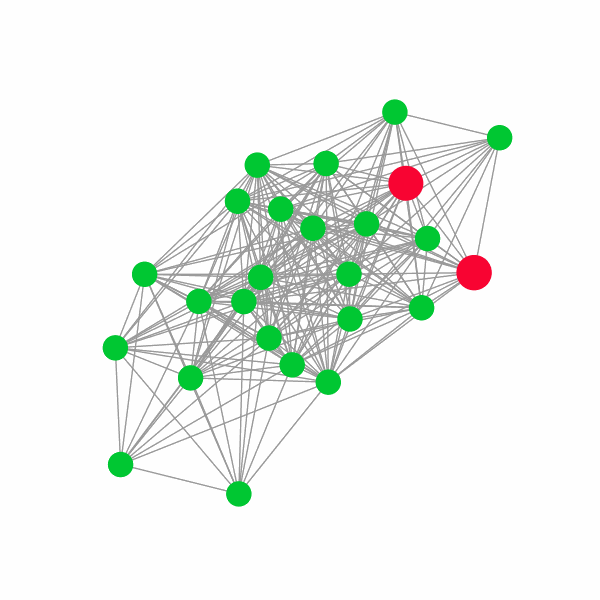

'diffusion.gif'

In [ ]:
viral_pred = int(prediction)   # from your model
history = simulate_diffusion(G, viral_pred)
generate_diffusion_gif(history)